# Selected XGBoost interpretation

This notebook explains the frozen market-only XGBoost model refitted on the combined training and validation samples. SHAP values are calculated on a test-sample subset stratified jointly by quarter and predicted-risk decile. The analysis is descriptive and is not used to modify the model. SHAP values explain prediction behavior rather than causal economic effects.

In [1]:
from pathlib import Path
import re
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.tabular_selection import PREDICTION, TARGET, transform_features
from src.utils.configuration import get_paths_config, get_project_config
from src.visualization.style import (
    COLOR_PALETTE, SINGLE_PANEL_SIZE, apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
project = get_project_config()
modeling_tables = paths.tables / 'modeling'
set_matplotlib_style()
display_names = {
    'market_cap_usd': 'Log market capitalization',
    'return_21d': 'Return (21 days)',
    'momentum_252_21d': 'Momentum (252--21 days)',
    'downside_volatility_63d': 'Downside volatility (63 days)',
    'market_beta_252d': 'Market beta (252 days)',
    'maximum_drawdown_252d': 'Maximum drawdown (252 days)',
    'negative_return_share_63d': 'Negative-return share (63 days)',
}

## Load and verify the frozen model

In [2]:
bundle = joblib.load(paths.models / 'final_selected_xgboost_market.joblib')
model = bundle['model']
preprocessing = bundle['preprocessing']
features = tuple(preprocessing['features'])
test = pd.read_parquet(
    paths.processed / 'modeling' / 'modeling_sample.parquet',
    columns=['report_period', 'information_date', 'permno', 'sample_split', *features],
).loc[lambda frame: frame['sample_split'].eq('test')].drop(columns='sample_split')
saved_predictions = pd.read_parquet(
    modeling_tables / 'final_models_test_predictions.parquet'
).loc[lambda frame: frame['model'].eq('XGBoost'),
      ['report_period', 'information_date', 'permno', PREDICTION]]
test = test.merge(
    saved_predictions,
    on=['report_period', 'information_date', 'permno'],
    how='inner', validate='one_to_one',
)
all_features = transform_features(test, preprocessing)
reproduced = np.clip(model.predict(all_features), 0, 1)
maximum_prediction_difference = np.max(
    np.abs(reproduced - test[PREDICTION].to_numpy())
)
if maximum_prediction_difference > 1e-6:
    raise RuntimeError('The saved test predictions could not be reproduced.')
test['predicted_decile'] = np.ceil(
    10 * test.groupby('report_period')[PREDICTION].rank(method='first', pct=True)
).astype(int).clip(1, 10)
print(f'Test observations: {len(test):,}')
print(f'Maximum prediction difference: {maximum_prediction_difference:.2e}')

Test observations: 30,511
Maximum prediction difference: 0.00e+00


## Construct the stratified interpretation sample

In [3]:
interpretation_sample = (
    test.groupby(['report_period', 'predicted_decile'], group_keys=False, sort=True)
    .sample(n=60, random_state=project.seed)
    .sort_values(['report_period', 'predicted_decile', 'permno'])
    .reset_index(drop=True)
)
feature_values = transform_features(interpretation_sample, preprocessing)
model_features = pd.DataFrame(
    feature_values,
    columns=[display_names[feature] for feature in features],
)
explainer = shap.TreeExplainer(model)
shap_values = explainer(model_features)
reconstructed = (
    np.asarray(shap_values.base_values)
    + np.asarray(shap_values.values).sum(axis=1)
)
shap_difference = np.max(
    np.abs(reconstructed - model.predict(model_features.to_numpy()))
)
if shap_difference > 1e-5:
    raise RuntimeError('SHAP values do not reconstruct model predictions.')
shap_output = interpretation_sample[[
    'report_period', 'information_date', 'permno', 'predicted_decile'
]].copy()
for index, feature in enumerate(features):
    shap_output[f'shap_{feature}'] = shap_values.values[:, index]
shap_output.to_parquet(
    modeling_tables / 'selected_xgboost_test_shap_values.parquet', index=False
)
print(f'Interpretation observations: {len(interpretation_sample):,}')
print(f'Maximum SHAP reconstruction difference: {shap_difference:.2e}')

Interpretation observations: 4,800
Maximum SHAP reconstruction difference: 2.98e-07


## Global feature importance

,feature,mean_absolute_shap,importance_share
0,Downside volatility (63 days),0.0461,39.05%
1,Maximum drawdown (252 days),0.0347,29.40%
2,Log market capitalization,0.0145,12.32%
3,Momentum (252--21 days),0.0090,7.59%
4,Market beta (252 days),0.0065,5.47%
5,Return (21 days),0.0061,5.13%
6,Negative-return share (63 days),0.0012,1.03%


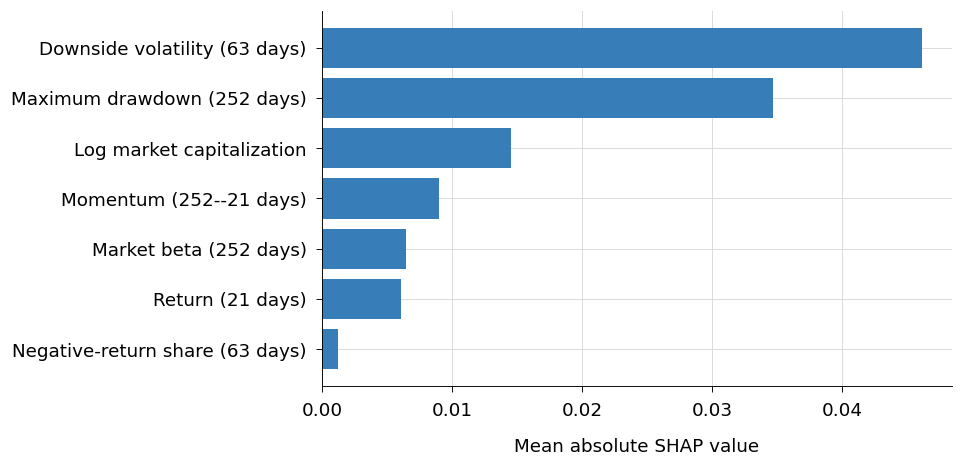

In [4]:
importance = pd.DataFrame({
    'feature': model_features.columns,
    'mean_absolute_shap': np.abs(shap_values.values).mean(axis=0),
})
importance['importance_share'] = (
    importance['mean_absolute_shap'] / importance['mean_absolute_shap'].sum()
)
importance = importance.sort_values('mean_absolute_shap', ascending=False).reset_index(drop=True)
importance.to_csv(
    modeling_tables / 'selected_xgboost_shap_importance.csv', index=False
)
importance.rename(columns={
    'feature': 'Feature', 'mean_absolute_shap': 'Mean absolute SHAP',
    'importance_share': 'Importance share',
}).to_latex(
    paths.tables / '04_07_xgboost_shap_importance.tex',
    index=False, escape=True, float_format='%.4f',
    caption='Global SHAP importance for the selected XGBoost model.',
    label='tab:xgboost-shap-importance',
)
display(importance.style.format({
    'mean_absolute_shap': '{:.4f}', 'importance_share': '{:.2%}',
}))

plot_data = importance.sort_values('mean_absolute_shap')
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.barh(plot_data['feature'], plot_data['mean_absolute_shap'],
          color=COLOR_PALETTE[0])
axis.set_xlabel('Mean absolute SHAP value')
axis.set_ylabel('')
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_11_xgboost_global_shap_importance.pdf')
plt.show()

## Distribution and direction of feature contributions

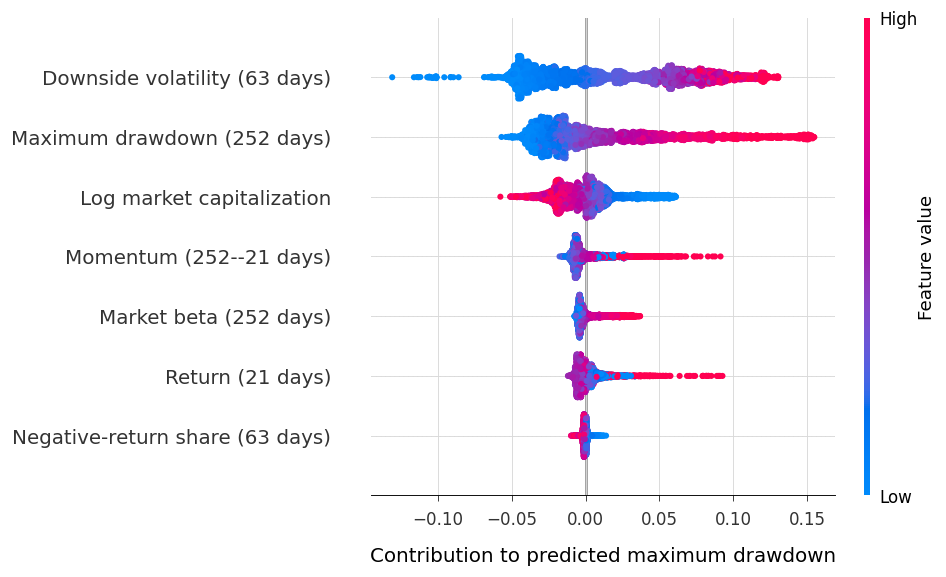

In [5]:
shap.plots.beeswarm(
    shap_values, max_display=len(features), show=False, plot_size=(9, 5.5)
)
figure = plt.gcf()
axis = plt.gca()
axis.set_xlabel('Contribution to predicted maximum drawdown')
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_11_xgboost_shap_beeswarm.pdf')
plt.show()

## Dependence patterns for the leading features

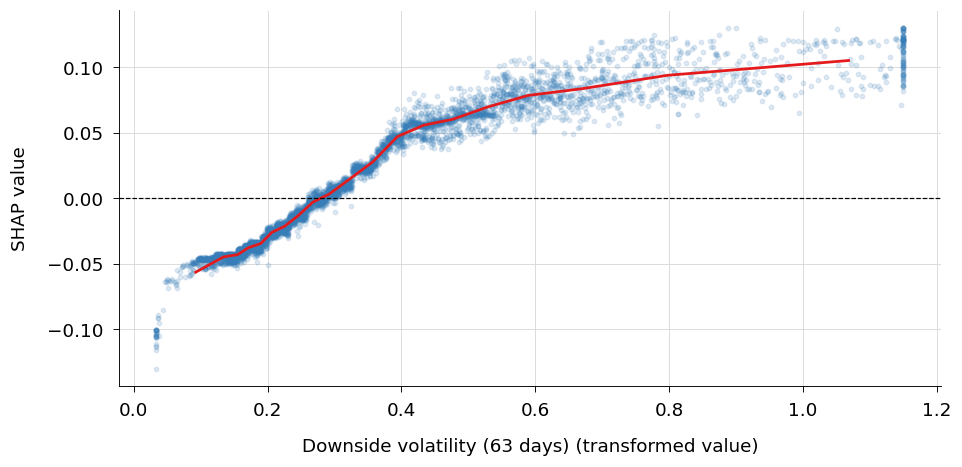

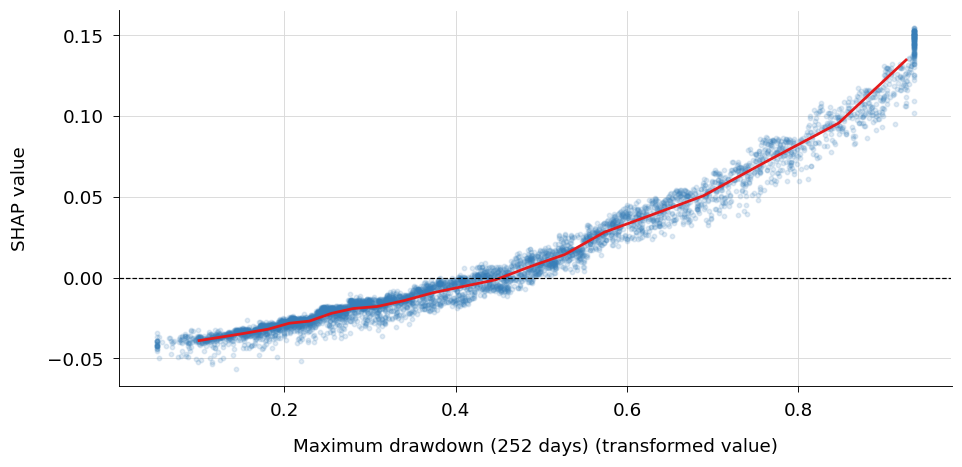

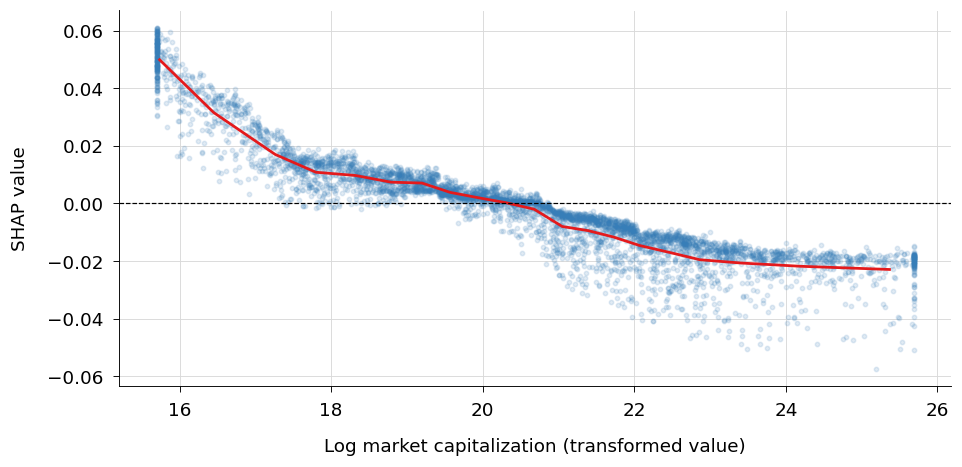

,feature,feature_shap_spearman
0,Downside volatility (63 days),0.989
1,Maximum drawdown (252 days),0.986
2,Log market capitalization,-0.952


In [6]:
direction_rows = []
for rank, feature in enumerate(importance.head(3)['feature'], start=1):
    feature_index = model_features.columns.get_loc(feature)
    values = model_features[feature]
    contributions = pd.Series(shap_values.values[:, feature_index])
    direction_rows.append({
        'feature': feature,
        'feature_shap_spearman': values.corr(contributions, method='spearman'),
    })
    bins = pd.qcut(values.rank(method='first'), 20, labels=False)
    binned = pd.DataFrame({
        'feature_value': values, 'shap_value': contributions, 'bin': bins,
    }).groupby('bin', as_index=False).agg(
        feature_value=('feature_value', 'mean'), shap_value=('shap_value', 'mean'),
    )
    figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
    axis.scatter(values, contributions, s=8, alpha=0.15, color=COLOR_PALETTE[0])
    axis.plot(binned['feature_value'], binned['shap_value'], color=COLOR_PALETTE[1])
    axis.axhline(0, color='black', linewidth=0.8, linestyle='--')
    axis.set_xlabel(f'{feature} (transformed value)')
    axis.set_ylabel('SHAP value')
    apply_matplotlib_layout(figure)
    slug = re.sub(r'[^a-z0-9]+', '_', feature.lower()).strip('_')
    figure.savefig(paths.figures / f'04_11_xgboost_shap_dependence_{rank}_{slug}.pdf')
    plt.show()

direction = pd.DataFrame(direction_rows)
direction.to_csv(
    modeling_tables / 'selected_xgboost_shap_direction.csv', index=False
)
direction.rename(columns={
    'feature': 'Feature', 'feature_shap_spearman': 'Feature--SHAP Spearman',
}).to_latex(
    paths.tables / '04_07_xgboost_shap_direction.tex',
    index=False, escape=True, float_format='%.3f',
    caption='Direction of the leading SHAP dependence relationships.',
    label='tab:xgboost-shap-direction',
)
display(direction.style.format({'feature_shap_spearman': '{:.3f}'}))

## Stability across test quarters

,mean_quarterly_importance_rank_correlation,minimum_quarterly_importance_rank_correlation
0,0.981,0.964


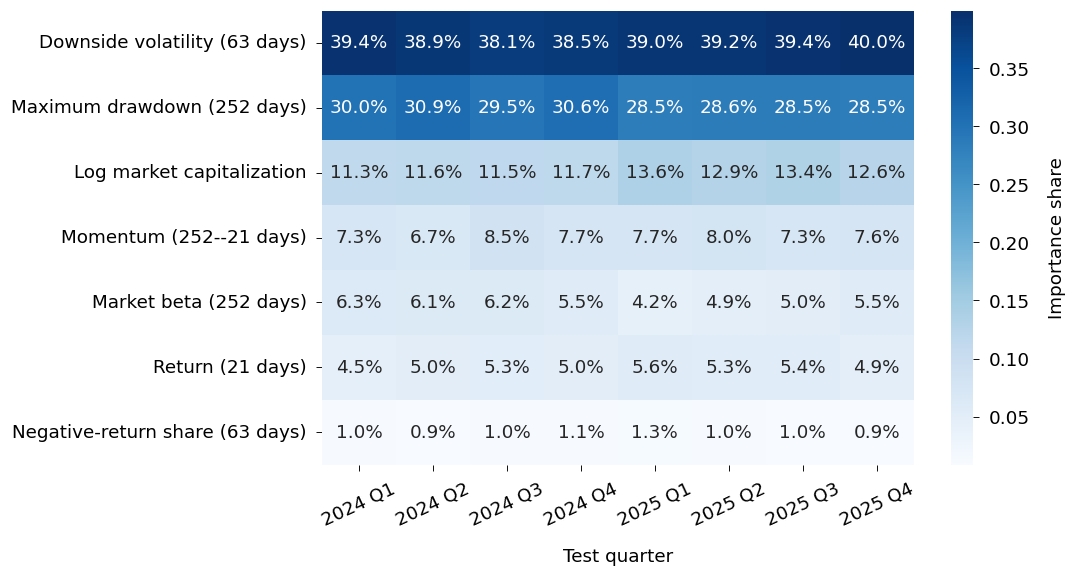

In [7]:
absolute_shap = pd.DataFrame(
    np.abs(shap_values.values), columns=model_features.columns
)
absolute_shap['report_period'] = interpretation_sample['report_period']
quarterly_importance = absolute_shap.groupby('report_period').mean()
quarterly_shares = quarterly_importance.div(quarterly_importance.sum(axis=1), axis=0)
quarterly_shares.to_csv(
    modeling_tables / 'selected_xgboost_quarterly_shap_importance.csv'
)
rank_correlations = quarterly_shares.T.corr(method='spearman')
off_diagonal = rank_correlations.to_numpy()[
    np.triu_indices(len(rank_correlations), k=1)
]
stability = pd.DataFrame([{
    'mean_quarterly_importance_rank_correlation': off_diagonal.mean(),
    'minimum_quarterly_importance_rank_correlation': off_diagonal.min(),
}])
stability.to_csv(
    modeling_tables / 'selected_xgboost_shap_stability.csv', index=False
)
display(stability.style.format('{:.3f}'))

heatmap = quarterly_shares.T
feature_order = heatmap.mean(axis=1).sort_values(ascending=False).index
heatmap = heatmap.loc[feature_order]
heatmap.columns = (
    pd.to_datetime(heatmap.columns).to_period('Q').astype(str)
    .str.replace('Q', ' Q', regex=False)
)
figure, axis = plt.subplots(figsize=(10, 5.5))
sns.heatmap(
    heatmap, cmap='Blues', annot=True, fmt='.1%',
    annot_kws={'fontsize': 12},
    cbar_kws={'label': 'Importance share'}, ax=axis,
)
axis.set_xlabel('Test quarter')
axis.set_ylabel('')
axis.tick_params(axis='x', rotation=25)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_11_xgboost_quarterly_shap_importance_heatmap.pdf'
)
plt.show()